In [2]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar
import matplotlib.path as mpath
import matplotlib.transforms as mtransforms

In [3]:
#load data
MASK_PATH = "/mnt/data7/nfs4/avh_lst/sdupuis/auxiliary/watermask50.tif"
clim = xr.open_dataset('../outputs/combined_monthly_day_2008_2020.nc')

In [4]:
clim

<xarray.Dataset> Size: 10MB
Dimensions:      (time: 156, latitude: 90, longitude: 180)
Coordinates:
    band         int64 8B ...
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01
    lat          (latitude) float32 360B ...
    lon          (longitude) float32 720B ...
    year         int16 2B ...
    month        int8 1B ...
  * latitude     (latitude) float32 360B -89.0 -87.0 -85.0 ... 85.0 87.0 89.0
  * longitude    (longitude) float32 720B -179.0 -177.0 -175.0 ... 177.0 179.0
Data variables:
    LST          (latitude, longitude, time) float32 10MB ...

In [5]:
climatology = clim.groupby("time.season").mean("time")

In [6]:
print("Loading water mask...")
clouds = xr.open_dataset('../data/ice_flc_percent_2008_2020_2deg.nc')
example = clouds['ice_flc_percent'].isel(year=1, month=1)

water_mask = rioxarray.open_rasterio(MASK_PATH)

water_mask = water_mask.rename({'y':'lat', 'x':'lon'})
water_mask = water_mask.isel(lat=slice(None, None, -1))
water_interp = water_mask.interp(lat=example.coords['latitude'], lon=example.coords['longitude'], method='nearest')

water_mask_true = clim['LST'].isel(time=0).copy(data=np.array(np.squeeze(water_interp)))
ls_mask = water_mask_true.where(water_mask_true>0, np.nan)

# Apply mask
clim_masked = climatology['LST'] * ls_mask


Loading water mask...


/tmp/ipykernel_67967/3037072025.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


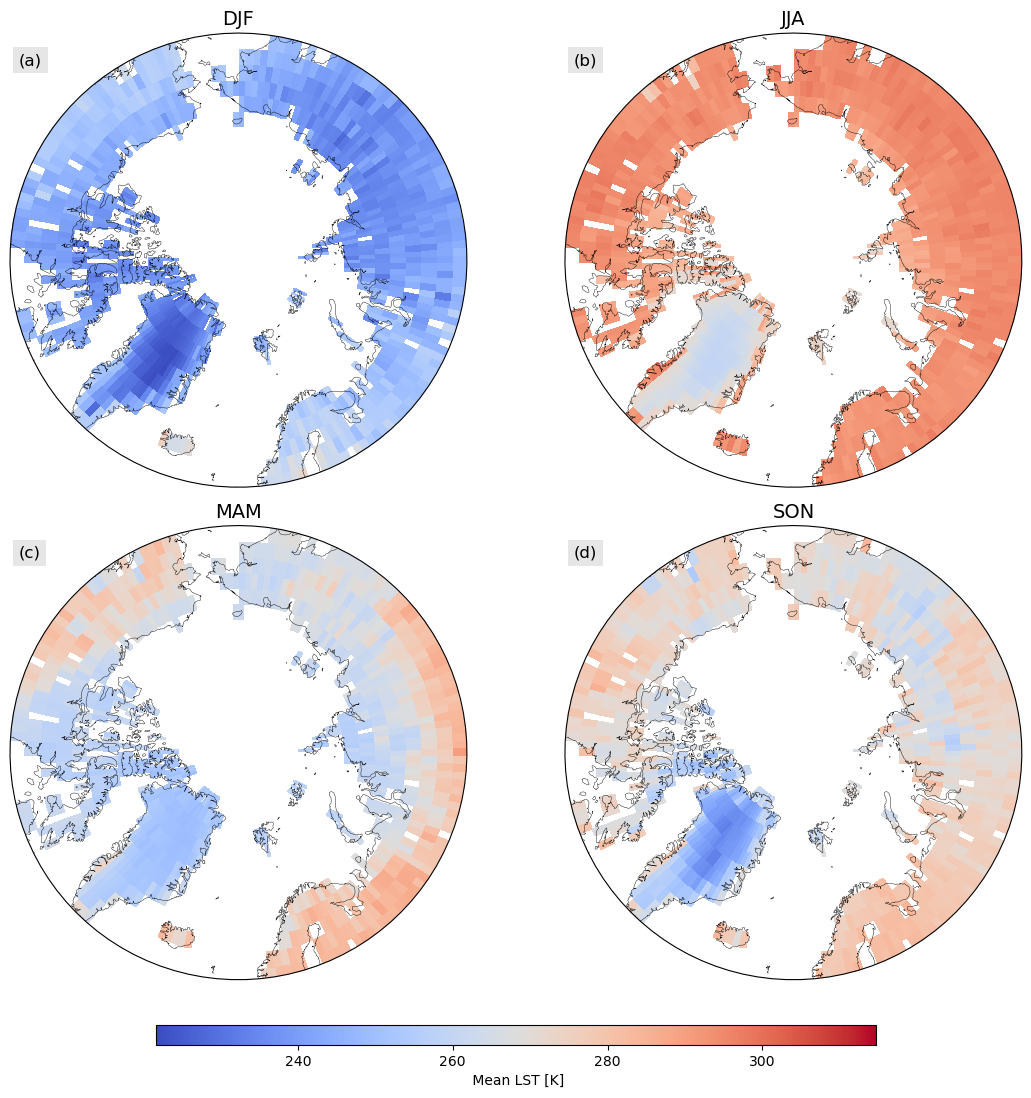

In [7]:
vmin = float(clim_masked.min())
vmax = float(clim_masked.max())

proj = ccrs.NorthPolarStereo()

# --- get seasons dynamically (important!) ---
seasons = list(clim_masked['season'].values)

# --- create mosaic layout (assumes 4 seasons) ---
fig, axs = plt.subplot_mosaic(
    [['(a)', '(b)'], ['(c)', '(d)']],
    figsize=(12, 10),
    subplot_kw=dict(projection=proj)
)

labels = ['(a)', '(b)', '(c)', '(d)']

# --- circular boundary ---
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# --- plotting loop ---
mappable = None

for i, (season, lab) in enumerate(zip(seasons, labels)):
    ax = axs[lab]

    da = clim_masked.sel(season=season)

    mappable = da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # --- map styling ---
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.3)

    ax.set_title(str(season), fontsize=14)

# --- panel labels ---
for lab, ax in axs.items():
    trans = mtransforms.ScaledTranslation(-10/72, 2/72, fig.dpi_scale_trans)
    ax.text(
        0.05, 0.95, lab,
        transform=ax.transAxes + trans,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(facecolor='0.9', edgecolor='none')
    )

# --- make space at bottom ---
fig.subplots_adjust(bottom=0.12)

# --- add colorbar axis manually ---
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.02])  # [left, bottom, width, height]

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label(' Mean LST [K]')

plt.tight_layout()
plt.savefig('meanstate_arctic_day.png', dpi=300)

In [8]:
# Night time data
clim_night = xr.open_dataset('../outputs/combined_monthly_NIGHT_2008_2020.nc')

In [9]:
climatology_night = clim_night.groupby("time.season").mean("time")

In [10]:
# Apply mask
clim_masked_night = climatology_night['LST'] * ls_mask


/tmp/ipykernel_67967/550756452.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


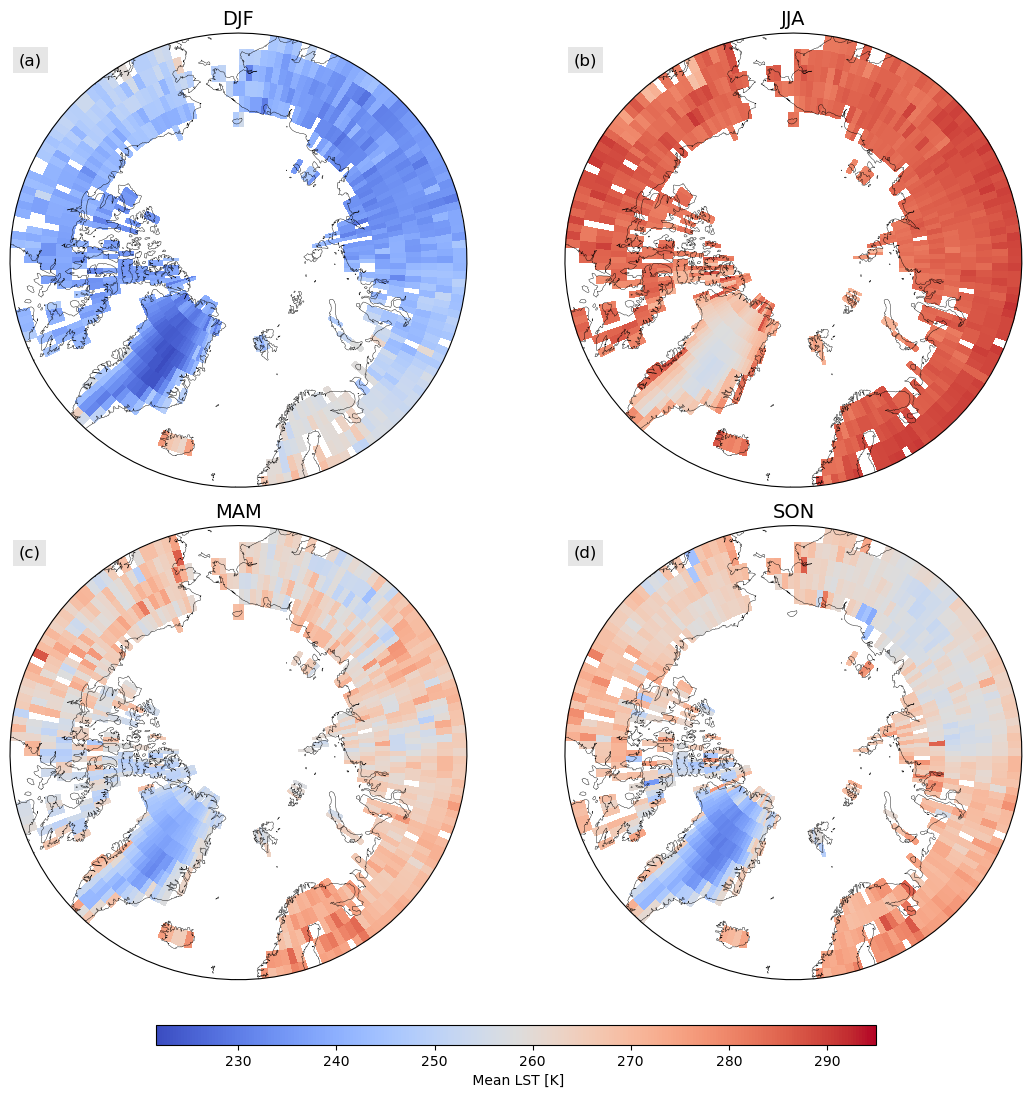

In [11]:
vmin = float(clim_masked_night.min())
vmax = float(clim_masked_night.max())

proj = ccrs.NorthPolarStereo()

# --- get seasons dynamically (important!) ---
seasons = list(clim_masked_night['season'].values)

# --- create mosaic layout (assumes 4 seasons) ---
fig, axs = plt.subplot_mosaic(
    [['(a)', '(b)'], ['(c)', '(d)']],
    figsize=(12, 10),
    subplot_kw=dict(projection=proj)
)

labels = ['(a)', '(b)', '(c)', '(d)']

# --- circular boundary ---
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# --- plotting loop ---
mappable = None

for i, (season, lab) in enumerate(zip(seasons, labels)):
    ax = axs[lab]

    da = clim_masked_night.sel(season=season)

    mappable = da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # --- map styling ---
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.3)

    ax.set_title(str(season), fontsize=14)

# --- panel labels ---
for lab, ax in axs.items():
    trans = mtransforms.ScaledTranslation(-10/72, 2/72, fig.dpi_scale_trans)
    ax.text(
        0.05, 0.95, lab,
        transform=ax.transAxes + trans,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(facecolor='0.9', edgecolor='none')
    )

# --- make space at bottom ---
fig.subplots_adjust(bottom=0.12)

# --- add colorbar axis manually ---
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.02])  # [left, bottom, width, height]

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label(' Mean LST [K]')

plt.tight_layout()
plt.savefig('meanstate_arctic_night.png', dpi=300)